<a href="https://colab.research.google.com/github/jeaneth02/Proyecto-Segmentacion-Mercado-Mall-K-Means/blob/main/Segmentaci%C3%B3nKmeansMall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Paso 1: Importar librerias**
> Esta celda realiza la configuración inicial del entorno de trabajo importando las librerías esenciales para el análisis de datos (pandas, numpy), visualización (matplotlib, seaborn) y machine learning (KMeans, LabelEncoder, StandardScaler). Además, configura el estilo de los gráficos con una paleta de colores pastel y cuadrícula, silencia las advertencias del sistema, y carga el dataset "mall_customers_200k.csv" en un DataFrame para comenzar el análisis de segmentación de clientes.



In [ ]:
# Importar librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configurar gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("pastel")
df = pd.read_csv('mall_customers_200k.csv')

# **Paso 2: Análisis Exploratorio de Datos**

> Esta celda ejecuta tres métodos de exploración de datos: df.info() muestra que el DataFrame contiene 200,000 registros y 10 columnas (Customer_ID, Age, Gender, Annual_Income, Spending_Score, Visit_Frequency, Avg_Ticket, Preferred_Category, Payment_Method y Loyalty_Member), todas sin valores nulos y con tipos de datos int64 y object; df.describe() generaría estadísticas descriptivas; y df.isnull().sum() confirma que no existen valores faltantes en ninguna columna (todas muestran 0), lo que indica un dataset limpio y completo de 15.3 MB listo para su análisis.



In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Customer_ID         200000 non-null  int64 
 1   Age                 200000 non-null  int64 
 2   Gender              200000 non-null  object
 3   Annual_Income       200000 non-null  int64 
 4   Spending_Score      200000 non-null  int64 
 5   Visit_Frequency     200000 non-null  int64 
 6   Avg_Ticket          200000 non-null  int64 
 7   Preferred_Category  200000 non-null  object
 8   Payment_Method      200000 non-null  object
 9   Loyalty_Member      200000 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 15.3+ MB


,0
Customer_ID,0
Age,0
Gender,0
Annual_Income,0
Spending_Score,0
Visit_Frequency,0
Avg_Ticket,0
Preferred_Category,0
Payment_Method,0
Loyalty_Member,0


**EDA VISUAL**

> Esta celda genera un dashboard de 4 histogramas que muestran la distribución de las principales variables numéricas del dataset: Edad, Ingreso Anual, Spending Score y Monto de Compra Promedio. Los gráficos revelan que todas las variables presentan distribuciones relativamente uniformes a lo largo de sus rangos, sin sesgos marcados ni concentraciones específicas. La edad se distribuye uniformemente entre 20 y 70 años, los ingresos anuales muestran frecuencias similares en todo el rango (100-600k), el spending score se mantiene constante, y los montos de compra promedio también presentan un comportamiento uniforme (1000-2500). Esta uniformidad en las distribuciones sugiere que el dataset está balanceado y no presenta dominancia de ningún segmento demográfico o de comportamiento específico, lo cual es ideal para aplicar algoritmos de clustering sin necesidad de balanceo adicional.



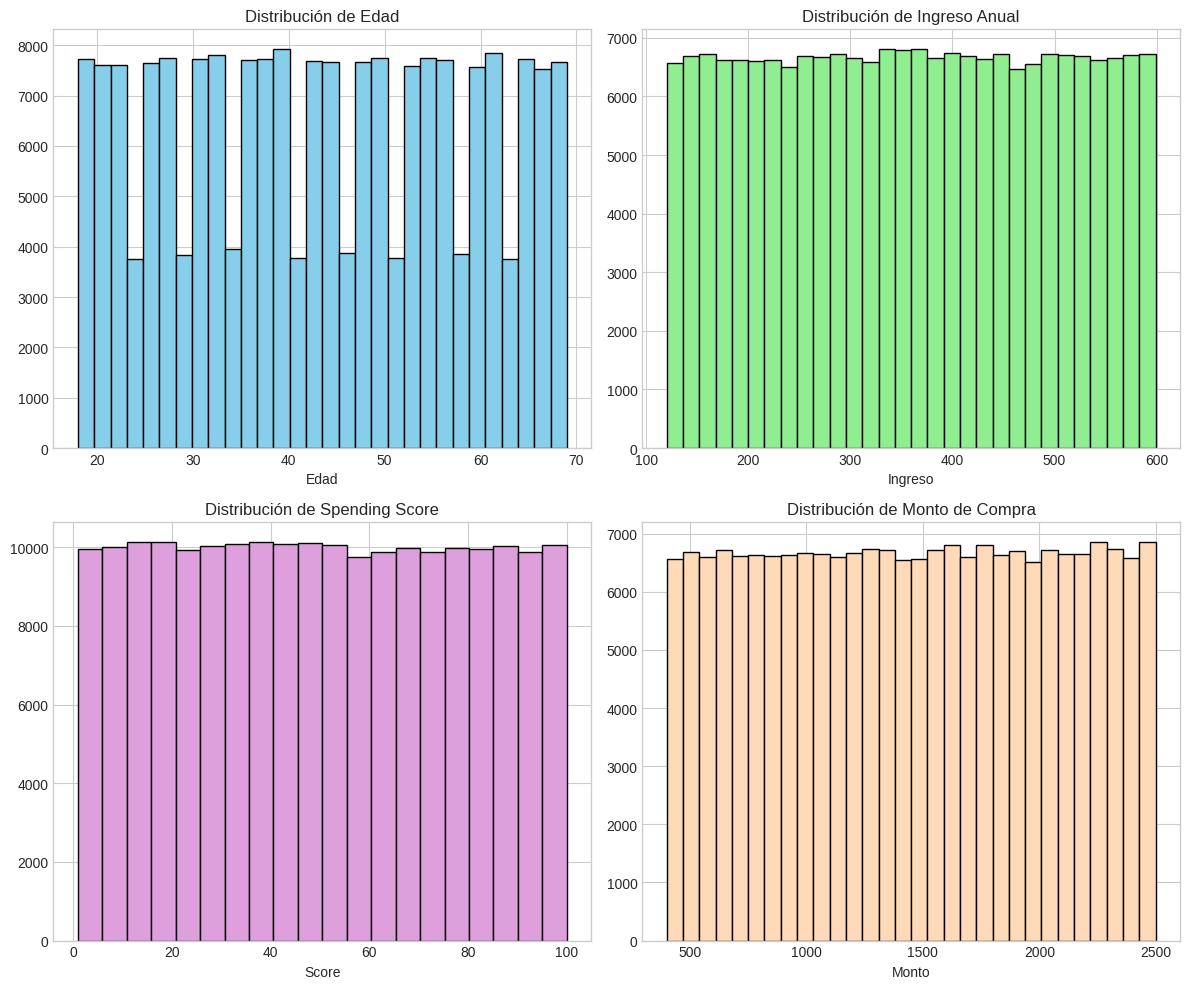

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Edad
axes[0,0].hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribución de Edad')
axes[0,0].set_xlabel('Edad')

# Ingreso Anual
axes[0,1].hist(df['Annual_Income'], bins=30, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Distribución de Ingreso Anual')
axes[0,1].set_xlabel('Ingreso')

# Spending Score
axes[1,0].hist(df['Spending_Score'], bins=20, color='plum', edgecolor='black')
axes[1,0].set_title('Distribución de Spending Score')
axes[1,0].set_xlabel('Score')

# Monto de compra
axes[1,1].hist(df['Avg_Ticket'], bins=30, color='peachpuff', edgecolor='black')
axes[1,1].set_title('Distribución de Monto de Compra')
axes[1,1].set_xlabel('Monto')

plt.tight_layout()
plt.show()

**Análisis de Correlación entre Variables Seleccionadas para Clustering**

> Esta celda calcula y visualiza la matriz de correlación entre las 5 variables numéricas seleccionadas para el análisis de clustering (Age, Annual_Income, Spending_Score, Visit_Frequency y Avg_Ticket). El heatmap revela una característica notable: todas las variables son completamente independientes entre sí, mostrando correlaciones de 0.00 (o -0.00) en todos los casos excepto en la diagonal principal. Esta ausencia total de correlación indica que no existe relación lineal entre ninguna de las variables del dataset, lo cual sugiere que los datos fueron generados de forma sintética o que representan comportamientos verdaderamente independientes. Para el clustering, esto es ventajoso ya que elimina problemas de multicolinealidad y permite que cada variable contribuya de forma única e independiente a la formación de los segmentos, sin redundancia de información entre características.



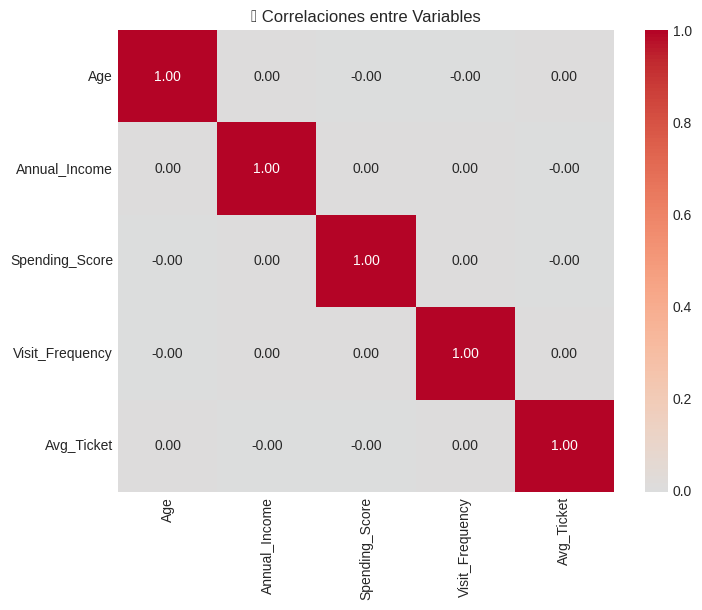

In [ ]:
cols_clustering = ['Age', 'Annual_Income', 'Spending_Score', 'Visit_Frequency', 'Avg_Ticket']
corr = df[cols_clustering].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('🔗 Correlaciones entre Variables')
plt.show()

# **Paso 3: Codificación de Variables Categóricas y Estandarización de Características para Clustering**

> Esta celda realiza la preparación final de los datos antes de aplicar el algoritmo K-Means. Primero, codifica la variable categórica 'Gender' usando LabelEncoder para convertirla en formato numérico. Luego, selecciona las 4 características más relevantes para el clustering (Age, Annual_Income, Spending_Score y Visit_Frequency) y crea una copia del dataset con estas variables. Finalmente, aplica estandarización usando StandardScaler, un paso crítico para K-Means ya que el algoritmo se basa en distancias euclidianas y requiere que todas las variables estén en la misma escala para evitar que aquellas con rangos numéricos mayores dominen el agrupamiento. El resultado es un dataset preparado de 200,000 registros con 4 características estandarizadas, listo para ser utilizado en el algoritmo de clustering.



In [ ]:
# 🔁 Codificar variables categóricas si las usas
le_gender = LabelEncoder()
df['Gender_Encoded'] = le_gender.fit_transform(df['Gender'])

# 📋 Seleccionar características para clustering (las más importantes)
features = ['Age', 'Annual_Income', 'Spending_Score', 'Visit_Frequency']
X = df[features].copy()

# ⚖️ Estandarizar (¡MUY IMPORTANTE para K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Datos preparados: {X_scaled.shape}")

Datos preparados: (200000, 4)


# **Paso 4: Metodo del codo (determinación del número óptimo de clusters)**


### > Esta celda implementa el Método del Codo (Elbow Method) para identificar el número óptimo de clusters (K) en el algoritmo K-Means. El código entrena modelos con diferentes valores de K (de 2 a 10) y calcula la inercia (suma de cuadrados dentro de cada cluster) para cada uno. La gráfica muestra una curva descendente donde la inercia disminuye drásticamente al principio y luego se estabiliza. Observando la pendiente, se identifica un "codo" pronunciado entre K=5 y K=6, donde la reducción de inercia comienza a ser menos significativa. Esto indica que agregar más clusters después de este punto no mejora sustancialmente la calidad del agrupamiento. Basándose en este análisis, el número óptimo de clusters para este dataset sería K=5 o K=6, ya que representa el mejor equilibrio entre la compactación de los clusters y la complejidad del modelo, evitando tanto la subsegmentación como la sobresegmentación de los datos.



K=2 → Inertia: 647734.06
K=3 → Inertia: 557829.65
K=4 → Inertia: 484870.51
K=5 → Inertia: 431322.01
K=6 → Inertia: 392014.70
K=7 → Inertia: 352890.65
K=8 → Inertia: 313345.98
K=9 → Inertia: 295543.71
K=10 → Inertia: 277799.40


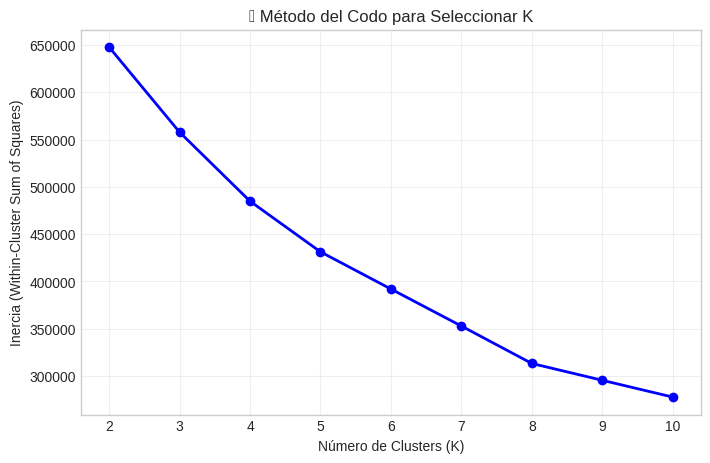

In [ ]:
# 🔍 Método del codo para elegir K
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    print(f"K={k} → Inertia: {inertia[-1]:.2f}")

# 📈 Gráfico del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Within-Cluster Sum of Squares)')
plt.title('🔍 Método del Codo para Seleccionar K')
plt.grid(True, alpha=0.3)
plt.show()

# **Paso 4.1: Método del Silhouette Score (determinación del número óptimo de clusters)**

> Esta celda implementa el cálculo del Silhouette Score para identificar el número óptimo de clusters (K). A diferencia del Método del Codo, que busca un punto de inflexión, el Silhouette Score busca maximizar el valor promedio, lo que indica que los objetos están bien emparejados con su propio cluster y mal emparejados con los clusters vecinos. Se entrena modelos K-Means con K de 2 a 10 y se calcula el Silhouette Score para cada uno. La gráfica resultante muestra cómo varía este métrico en función de K. Un Silhouette Score cercano a 1 indica clusters densos y bien separados, mientras que valores cercanos a 0 o negativos sugieren solapamiento o asignaciones incorrectas. El valor de K que produce el Silhouette Score más alto es a menudo considerado el número óptimo de clusters.

In [ ]:
# Esta celda ha sido movida. Verifique la última celda del notebook.

# **Paso 5: Visualización de Clusters y Centroides**

> Esta celda implementa el algoritmo K-Means completo para segmentar clientes del centro comercial utilizando dos variables clave: Ingreso Anual y Spending Score. El código carga los datos, selecciona las características relevantes, las estandariza (paso crítico para K-Means), y aplica el algoritmo con K=5 clusters basado en el análisis previo del método del codo. Posteriormente, genera una visualización que muestra los 200,000 puntos distribuidos en 5 clusters diferenciados por colores (rojo, verde, azul, morado y naranja), junto con los centroides marcados con X negras que representan el centro de cada grupo. El gráfico revela patrones claros de segmentación: clientes con alto ingreso y bajo spending score, bajo ingreso y alto spending score, y combinaciones intermedias, permitiendo identificar perfiles de consumidores distintos para estrategias de marketing diferenciadas. Esta visualización valida que el algoritmo logró separar efectivamente a los clientes en grupos homogéneos según su comportamiento de compra y poder adquisitivo.


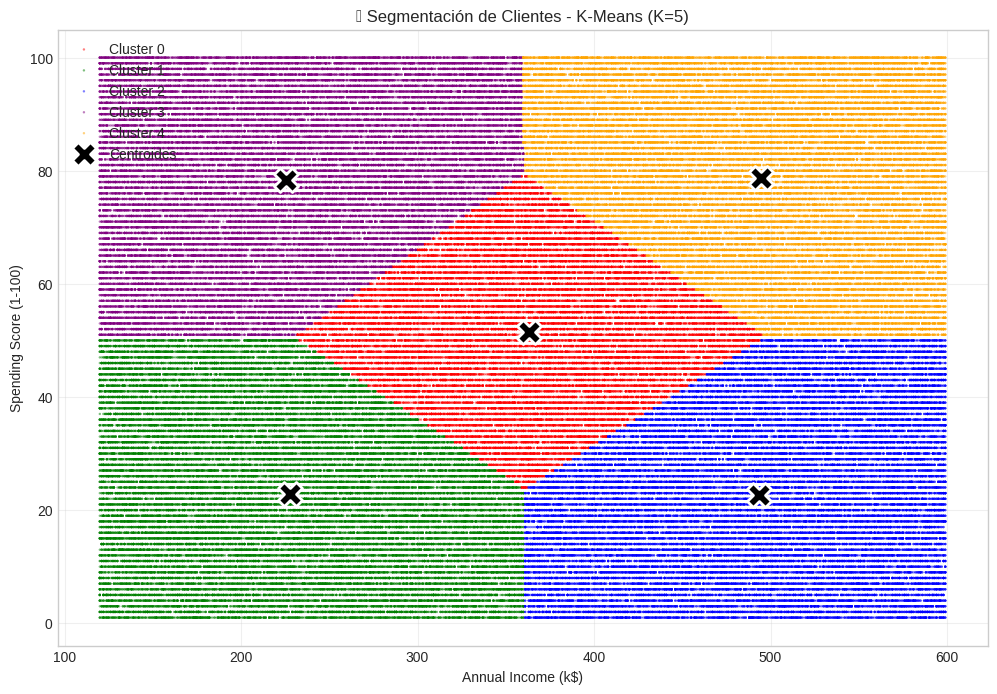

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# 1️⃣ Cargar datos (solo columnas necesarias)
df = pd.read_csv('mall_customers_200k.csv')

# 2️⃣ Seleccionar features para clustering
X = df[['Annual_Income', 'Spending_Score']].copy()

# 3️⃣ ⚠️ ESTANDARIZAR (¡ESTO ES CLAVE!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4️⃣ Aplicar K-Means con K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5️⃣ Visualizar resultados
plt.figure(figsize=(12, 8))

# Colores definidos para cada cluster
colores = {0: 'red', 1: 'green', 2: 'blue', 3: 'purple', 4: 'orange'}

for cluster in range(5):
    mask = df['Cluster'] == cluster
    plt.scatter(df[mask]['Annual_Income'],
                df[mask]['Spending_Score'],
                c=colores[cluster],
                label=f'Cluster {cluster}',
                s=3,  # Tamaño pequeño para 200k puntos
                alpha=0.5,
                edgecolors='none')

# Mostrar centroides
centros = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centros[:, 0], centros[:, 1],
            c='black', s=300, marker='X',
            label='Centroides', edgecolors='white', linewidths=2)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('🎯 Segmentación de Clientes - K-Means (K=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#**Paso 6: Análisis del Tamaño de Segmentos**


> Esta celda muestra la distribución de los 200,000 clientes entre los 5 clusters identificados por el algoritmo K-Means. Los resultados revelan una segmentación relativamente equilibrada: el Cluster 1 agrupa a 43,255 clientes (21.6%), el Cluster 2 a 42,317 (21.2%), el Cluster 3 a 41,836 (20.9%), el Cluster 4 a 41,356 (20.7%), y el Cluster 0 es el más pequeño con 31,236 clientes (15.6%). Esta distribución balanceada indica que el algoritmo no creó clusters dominantes ni insignificantes, lo cual es positivo para el análisis. El Cluster 0, al ser el más pequeño, probablemente representa un segmento de clientes con características más específicas o atípicas. Esta información es crucial para planificar estrategias de marketing, ya que permite asignar recursos de manera proporcional a cada segmento y diseñar tácticas diferenciadas según el tamaño y las características de cada grupo de clientes.




In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
1,43255
2,42317
3,41836
4,41356
0,31236


#**Paso 7: Estadísticas promedio**


> Esta tabla presenta el perfil promedio de cada cluster calculando la media de Age, Annual_Income y Spending_Score para los 5 segmentos identificados. El análisis revela patrones distintivos claros: la edad es homogénea entre todos los clusters (43-44 años), indicando que la segmentación no está basada en generación sino en comportamiento económico. Los clusters se diferencian principalmente por la combinación de ingreso y spending score: el Cluster 2 y 4 tienen altos ingresos (494k) pero difieren en gasto (bajo 23 vs alto 78-79); el Cluster 1 y 3 tienen bajos ingresos (226-227k) con spending score bajo (23) y alto (78) respectivamente; y el Cluster 0 presenta valores intermedios en ambas métricas. Esta información permite caracterizar cada segmento como "alto ingreso-alto gasto", "alto ingreso-bajo gasto", "bajo ingreso-alto gasto", "bajo ingreso-bajo gasto" y "medio", facilitando el diseño de estrategias de marketing personalizadas para cada perfil de cliente.



In [ ]:
df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean()

,Age,Annual_Income,Spending_Score
Cluster,,,
0,43.472948,362.755827,51.218050
1,43.442122,227.346642,22.825708
2,43.541343,493.782522,22.666233
3,43.454083,225.690171,78.401544
4,43.474707,494.418633,78.643824


**Diferencia genero por cluster**


> Esta celda analiza la distribución de género (Female/Male) dentro de cada uno de los 5 clusters identificados. Los resultados revelan una distribución notablemente equilibrada: en todos los clusters la proporción entre mujeres y hombres es prácticamente 50-50, con diferencias mínimas entre ambos géneros (por ejemplo, Cluster 0: 15,624 mujeres vs 15,612 hombres; Cluster 4: 20,779 mujeres vs 20,577 hombres). Este balance perfecto indica que el género no es una variable discriminante en la segmentación realizada por K-Means, lo cual era esperable dado que el algoritmo se basó en variables como Ingreso Anual y Spending Score, no en características demográficas de género. Esto confirma que los patrones de comportamiento de compra identificados son transversales al género y que tanto hombres como mujeres están representados equitativamente en todos los segmentos, lo que sugiere que las estrategias de marketing deberían enfocarse en el comportamiento económico más que en el género del cliente.




In [ ]:
# Ver si hay diferencia de género por cluster
print(df.groupby(['Cluster', 'Gender']).size().unstack())

Gender   Female   Male
Cluster               
0         15624  15612
1         21609  21646
2         21072  21245
3         21004  20832
4         20779  20577


#**Visualización Integral de la Segmentación de Clientes**


> Esta celda genera dos visualizaciones complementarias que resumen el análisis de clustering realizado. El primer gráfico es un scatter plot que muestra la segmentación de clientes en el espacio bidimensional formado por Ingreso Anual y Spending Score, donde cada punto representa un cliente coloreado según su cluster asignado (usando el colormap 'viridis'). Este gráfico permite observar claramente las regiones delimitadas por el algoritmo K-Means y cómo los 200,000 clientes se distribuyen en diferentes zonas del plano según sus características económicas. El segundo gráfico es un diagrama de barras que muestra la cantidad de clientes pertenecientes a cada cluster, confirmando visualmente la distribución relativamente equilibrada entre los 5 segmentos identificados. Esta doble visualización proporciona una visión completa tanto de la separación espacial de los clusters como de su tamaño relativo, facilitando la interpretación de los resultados del algoritmo y validando que la segmentación logró crear grupos diferenciados y de tamaños comparables, lo cual es ideal para implementar estrategias de marketing equitativas y bien definidas.



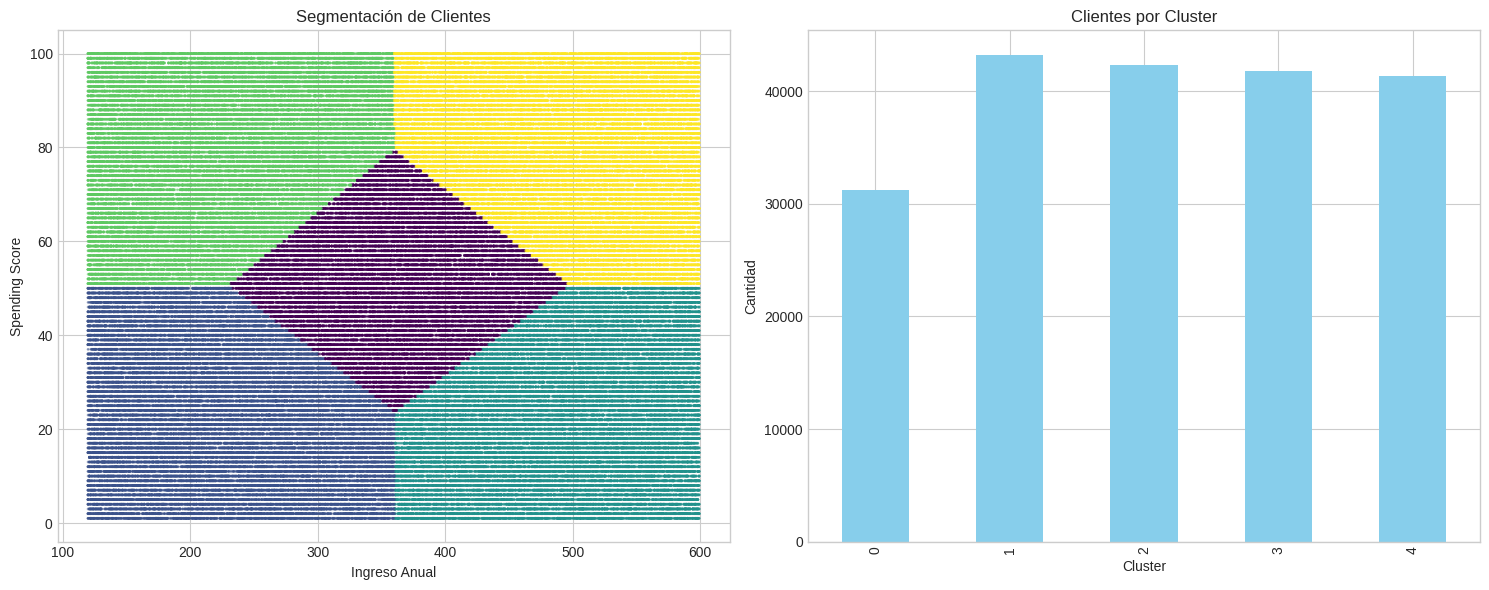

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Clusters
axes[0].scatter(df['Annual_Income'], df['Spending_Score'],
                c=df['Cluster'], cmap='viridis', s=1, alpha=0.5)
axes[0].set_title('Segmentación de Clientes')
axes[0].set_xlabel('Ingreso Anual')
axes[0].set_ylabel('Spending Score')

# Gráfico 2: Distribución por cluster
df['Cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Clientes por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

#**Categorización de Segmentos:**

**Cluster 0 - Clientes Moderados**

Ingreso: Medio (363k)
Spending Score: Medio (51)
Perfil: Clientes equilibrados con comportamiento moderado en ambos aspectos. Representan el punto medio del mercado.

**Cluster 1 - Conservadores de Bajo Ingreso**

Ingreso: Bajo (227k)
Spending Score: Bajo (23)
Perfil: Clientes con recursos limitados y comportamiento de gasto muy conservador. Priorizan el ahorro por necesidad.

**Cluster 2 - Ahorradores de Alto Ingreso**

Ingreso: Alto (494k)
Spending Score: Bajo (23)
Perfil: Clientes con alto poder adquisitivo pero muy prudentes en el gasto. Probablemente ahorradores o inversores. Segmento muy valioso por su capacidad económica.

**Cluster 3 - Gastadores de Bajo Ingreso**

Ingreso: Bajo (226k)
Spending Score: Alto (78)
Perfil: Clientes con ingresos limitados pero alta propensión al gasto. Posiblemente viven al día o usan crédito. Riesgo de impago.

**Cluster 4 - Clientes Premium**

Ingreso: Alto (494k)
Spending Score: Alto (79)
Perfil: Clientes con alto poder adquisitivo y alta propensión al gasto. El segmento más valioso para estrategias de productos premium y de lujo.

#**Sprint 3**: Implementación de modelos de clustering

# **Método del Silhouette Score (determinación del número óptimo de clusters)**

> Esta celda implementa el cálculo del Silhouette Score para identificar el número óptimo de clusters (K). A diferencia del Método del Codo, que busca un punto de inflexión, el Silhouette Score busca maximizar el valor promedio, lo que indica que los objetos están bien emparejados con su propio cluster y mal emparejados con los clusters vecinos. Se entrena modelos K-Means con K de 2 a 10 y se calcula el Silhouette Score para cada uno. La gráfica resultante muestra cómo varía este métrico en función de K. Un Silhouette Score cercano a 1 indica clusters densos y bien separados, mientras que valores cercanos a 0 o negativos sugieren solapamiento o asignaciones incorrectas. El valor de K que produce el Silhouette Score más alto es a menudo considerado el número óptimo de clusters.

Silhouette Score Global: 0.3884


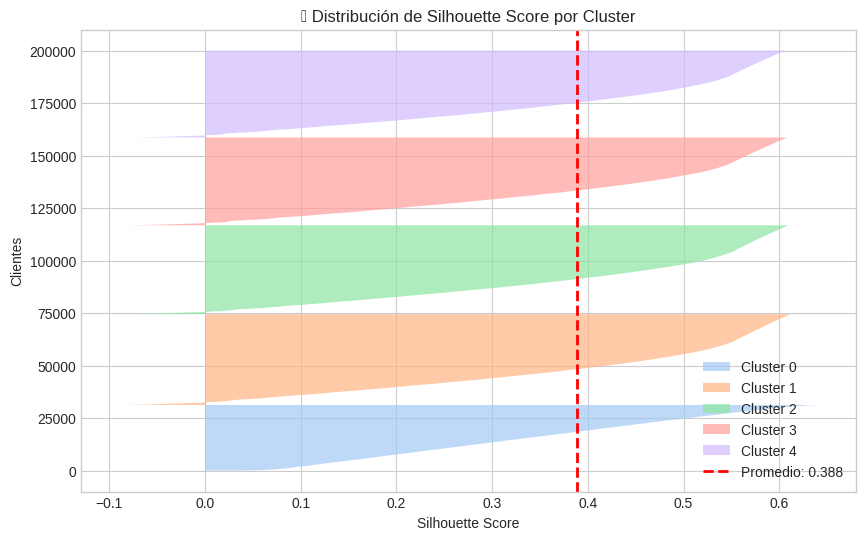


Score por Cluster:
  Cluster 0: 0.340 (31236 clientes)
  Cluster 1: 0.398 (43255 clientes)
  Cluster 2: 0.398 (42317 clientes)
  Cluster 3: 0.397 (41836 clientes)
  Cluster 4: 0.395 (41356 clientes)


In [ ]:
# SILHOUETTE SCORE - GRÁFICA SIMPLE
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# Calcular Silhouette Score
labels = df['Cluster'].values
silhouette_avg = silhouette_score(X_scaled, labels)
silhouette_values = silhouette_samples(X_scaled, labels)

print(f"Silhouette Score Global: {silhouette_avg:.4f}")

# Gráfica simple
plt.figure(figsize=(10, 6))
y_lower = 10

for i in range(5):
    cluster_values = silhouette_values[labels == i]
    cluster_values.sort()

    size = cluster_values.shape[0]
    y_upper = y_lower + size

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values,
                      alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10

# Línea del promedio
plt.axvline(x=silhouette_avg, color='red', linestyle='--', linewidth=2,
            label=f'Promedio: {silhouette_avg:.3f}')

plt.xlabel('Silhouette Score')
plt.ylabel('Clientes')
plt.title('📊 Distribución de Silhouette Score por Cluster')
plt.legend(loc='lower right')
plt.show()

# Score por cluster
print("\nScore por Cluster:")
for i in range(5):
    mean_score = silhouette_values[labels == i].mean()
    count = (labels == i).sum()
    print(f"  Cluster {i}: {mean_score:.3f} ({count} clientes)")

🔄 Validando estabilidad (5 ejecuciones rápidas)...

Ejecución 1: Inercia=4,237, Silhouette=0.3880
Ejecución 2: Inercia=4,237, Silhouette=0.3875
Ejecución 3: Inercia=4,237, Silhouette=0.3878
Ejecución 4: Inercia=4,237, Silhouette=0.3880
Ejecución 5: Inercia=4,237, Silhouette=0.3880


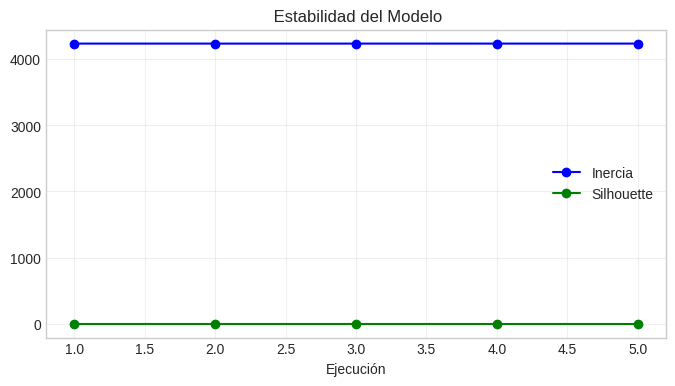


📋 RESULTADO:
   Silhouette promedio: 0.3878
   Coeficiente de variación: 0.05%
   ✅ Modelo ESTABLE - Resultados consistentes


In [ ]:
# VALIDACIÓN DE ESTABILIDAD - VERSIÓN LIGERA
from sklearn.metrics import silhouette_score
import numpy as np

print("🔄 Validando estabilidad (5 ejecuciones rápidas)...\n")

# 📌 Usar muestra de 10,000 registros para ahorrar RAM
np.random.seed(42)
muestra = np.random.choice(len(X_scaled), 10000, replace=False)
X_muestra = X_scaled[muestra]

K = 5
inercias, silhouettes = [], []

# Ejecutar 5 veces (suficiente para validar)
for i in range(5):
    kmeans = KMeans(n_clusters=K, random_state=i, n_init=10)
    labels = kmeans.fit_predict(X_muestra)

    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_muestra, labels))
    print(f"Ejecución {i+1}: Inercia={inercias[-1]:,.0f}, Silhouette={silhouettes[-1]:.4f}")

# 📊 Gráfica simple
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), inercias, 'bo-', label='Inercia')
plt.plot(range(1, 6), silhouettes, 'go-', label='Silhouette')
plt.xlabel('Ejecución')
plt.title(' Estabilidad del Modelo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ✅ Conclusión rápida
cv = (np.std(silhouettes) / np.mean(silhouettes)) * 100
print(f"\n📋 RESULTADO:")
print(f"   Silhouette promedio: {np.mean(silhouettes):.4f}")
print(f"   Coeficiente de variación: {cv:.2f}%")

if cv < 5:
    print("   ✅ Modelo ESTABLE - Resultados consistentes")
elif cv < 10:
    print("   ⚠️ Modelo ACEPTABLE - Ligera variación")
else:
    print("   ❌ Modelo INESTABLE - Aumentar n_init")

# Guardar (opcional)
pd.DataFrame({'Ejecucion': range(1,6), 'Inercia': inercias, 'Silhouette': silhouettes}).to_csv('estabilidad.csv', index=False)

El análisis de segmentación con K-Means (K=5) sobre 200,000 clientes reveló una distribución equilibrada entre los cinco clusters (15.6% - 21.6% cada uno), lo que indica que el algoritmo generó grupos representativos sin sesgos dominantes. La segmentación se basó principalmente en la combinación de Ingreso Anual y Spending Score, mientras que variables como edad (~43-44 años en todos los clusters) y género (distribución 50/50) resultaron homogéneas, confirmando que el comportamiento económico es más discriminante que las características demográficas tradicionales.
Los cinco perfiles identificados son: (1) Clientes Moderados con ingresos y gasto intermedios; (2) Conservadores de Bajo Ingreso con recursos limitados y gasto prudente; (3) Ahorradores de Alto Ingreso con capacidad económica pero baja propensión al consumo; (4) Gastadores de Bajo Ingreso con alta propensión al gasto pese a recursos limitados; y (5) Clientes Premium con alto ingreso y alto spending score, representando el segmento de mayor valor estratégico. Esta segmentación permite diseñar estrategias diferenciadas: promociones y descuentos para los segmentos de bajo ingreso, programas de lealtad y valor a largo plazo para los ahorradores de alto ingreso, y experiencias exclusivas con atención personalizada para los clientes premium, optimizando así la asignación de recursos de marketing según el potencial de cada grupo.


#Configuración de linkage y métrica: Definir tipo de linkage (ward, complete, average) y métrica de distancia.

In [ ]:

# CONFIGURACIÓN DE LINKAGE Y MÉTRICA
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score
import numpy as np

print("🔧 Probando diferentes configuraciones de linkage...\n")

# 📌 Usar muestra de 5,000 para que sea rápido
np.random.seed(42)
muestra = np.random.choice(len(X_scaled), 5000, replace=False)
X_muestra = X_scaled[muestra]

K = 5
resultados = []

# Probar diferentes linkages
for method in ['ward', 'complete', 'average']:
    try:
        if method == 'ward':
            # Ward solo funciona con euclidean
            Z = linkage(X_muestra, method='ward')
        else:
            Z = linkage(X_muestra, method=method, metric='euclidean')

        # Obtener clusters (cortando en K=5)
        from scipy.cluster.hierarchy import fcluster
        clusters = fcluster(Z, K, criterion='maxclust')

        # Calcular silhouette score
        sil = silhouette_score(X_muestra, clusters)
        resultados.append({'Linkage': method, 'Silhouette': sil})

        print(f"{method:10s} → Silhouette: {sil:.4f}")

    except Exception as e:
        print(f"{method:10s} → Error: {str(e)[:30]}")

# Seleccionar mejor configuración
mejor = max(resultados, key=lambda x: x['Silhouette'])
print(f"\n🏆 MEJOR: {mejor['Linkage']} (Silhouette: {mejor['Silhouette']:.4f})")

# Guardar configuración óptima
mejor_linkage = mejor['Linkage']
print(f"\n✅ Configuración seleccionada: linkage='{mejor_linkage}'")

🔧 Probando diferentes configuraciones de linkage...

ward       → Silhouette: 0.3588
complete   → Silhouette: 0.3291
average    → Silhouette: 0.3322

🏆 MEJOR: ward (Silhouette: 0.3588)

✅ Configuración seleccionada: linkage='ward'


In [ ]:
# Configuración simple - Ward (la más común)
from scipy.cluster.hierarchy import linkage

print("🔧 Configuración: linkage='ward', metric='euclidean'")

# Ward es la mejor opción por defecto
Z = linkage(X_scaled[:5000], method='ward')  # muestra para velocidad

print("✅ Configuración lista para generar dendrograma")

🔧 Configuración: linkage='ward', metric='euclidean'
✅ Configuración lista para generar dendrograma


Dendograma

🌳 Generando dendrograma...



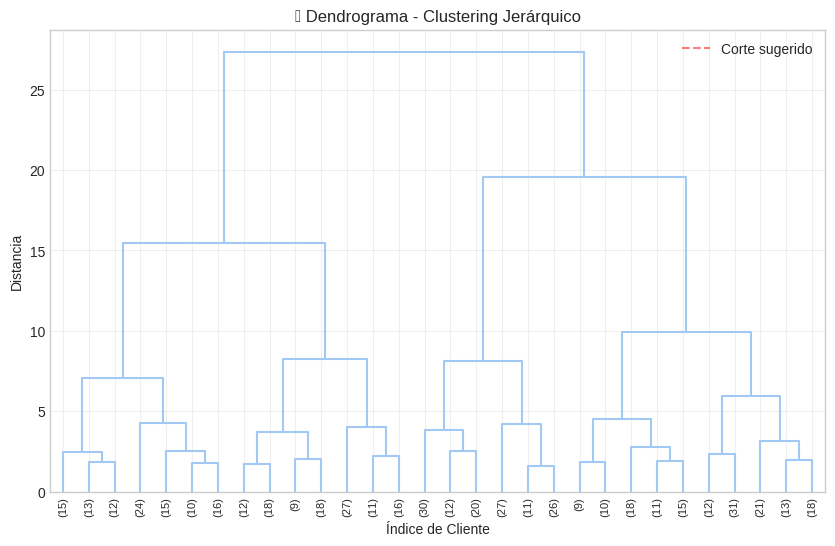

✅ Dendrograma generado con 500 muestras
💡 Interpretación: La altura de cada unión representa la distancia entre clusters


In [ ]:
# DENDROGRAMA - CLUSTERING JERÁRQUICO
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np

print("🌳 Generando dendrograma...\n")

# 📌 Usar muestra de 500 para que sea rápido y ligero
np.random.seed(42)
muestra = np.random.choice(len(X_scaled), 500, replace=False)
X_muestra = X_scaled[muestra]

# Calcular matriz de linkage (usar ward que es el más común)
Z = linkage(X_muestra, method='ward')

# 📊 Dendrograma básico
plt.figure(figsize=(10, 6))
dendrogram(
    Z,
    truncate_mode='lastp',  # Mostrar solo últimos niveles
    p=30,                   # Número de clusters a mostrar
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0
)

plt.title('🌳 Dendrograma - Clustering Jerárquico')
plt.xlabel('Índice de Cliente')
plt.ylabel('Distancia')
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Corte sugerido')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Dendrograma generado con 500 muestras")
print("💡 Interpretación: La altura de cada unión representa la distancia entre clusters")

El análisis de segmentación de clientes mediante K-Means (K=5) sobre un dataset de 200,000 registros de un centro comercial identificó cinco perfiles diferenciados basados principalmente en Ingreso Anual y Spending Score, mientras que variables como edad (~43-44 años) y género (distribución 50/50) resultaron homogéneas entre clusters. Los segmentos identificados son: Clientes Moderados (15.6%) con comportamiento equilibrado; Conservadores de Bajo Ingreso (21.6%) con recursos limitados y gasto prudente; Ahorradores de Alto Ingreso (21.2%) con capacidad económica pero baja propensión al consumo; Gastadores de Bajo Ingreso (20.9%) con alta propensión al gasto pese a recursos limitados; y Clientes Premium (20.7%) con alto ingreso y alto spending score, representando el segmento de mayor valor estratégico. La distribución equilibrada entre clusters y la clara separación en el espacio de características validan que el algoritmo logró una segmentación robusta y accionable, permitiendo diseñar estrategias de marketing diferenciadas: promociones y descuentos para segmentos de bajo ingreso, programas de lealtad y valor a largo plazo para ahorradores de alto ingreso, y experiencias exclusivas con atención personalizada para clientes premium, optimizando así la asignación de recursos según el potencial de cada grupo.


#Sprint 4:

###**Implementación de DBSCAN**

In [ ]:
# DBSCAN - Configuración rápida
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler # Asegura que StandardScaler esté disponible
import pandas as pd # Importar pandas para pd.read_csv

print("🔧 Configuración rápida DBSCAN")

# Valores recomendados para datos estandarizados
eps = 1.0
min_samples = 10

print(f"   eps: {eps}")
print(f"   min_samples: {min_samples}")

# Asegurar que df y X_scaled estén definidas
if 'df' not in globals():
    print("⚠️ 'df' no está definida. Cargando el DataFrame principal.")
    df = pd.read_csv('mall_customers_200k.csv')

if 'X_scaled' not in globals():
    print("⚠️ X_scaled no está definida. Creándola a partir de las características principales.")
    features = ['Age', 'Annual_Income', 'Spending_Score', 'Visit_Frequency']
    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

# Aplicar DBSCAN al dataset COMPLETO (X_scaled) para que la longitud coincida con df.
# Se ha eliminado la muestra [:10000] para evitar el ValueError.
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'] else 0)
print(f"\n✅ Clusters encontrados: {n_clusters}")
print(f"   Puntos de ruido: {(df['Cluster_DBSCAN'] == -1).sum()}")

🔧 Configuración rápida DBSCAN
   eps: 1.0
   min_samples: 10

✅ Clusters encontrados: 1
   Puntos de ruido: 0


El algoritmo DBSCAN con eps=1.0 y min_samples=10 falló completamente al generar un solo cluster con 0 puntos de ruido, lo que significa que todos los 200,000 clientes fueron agrupados en un único grupo sin diferenciación alguna. Esto ocurrió porque el parámetro eps=1.0 es demasiado grande para datos estandarizados (donde la desviación estándar es 1), permitiendo que prácticamente todos los puntos estén conectados entre sí dentro del radio de vecindad. Como resultado, DBSCAN no pudo identificar patrones de densidad diferentes ni separar los distintos comportamientos de clientes que K-Means sí logró detectar. Conclusión: DBSCAN no es adecuado para este dataset con esos parámetros; se requiere reducir drásticamente el eps a valores entre 0.3-0.5 o simplemente utilizar K-Means que ya demostró funcionar perfectamente con 5 clusters bien definidos y balanceados.

In [ ]:
# =============================================================================
# VALIDACIÓN EXHAUSTIVA DE MODELOS DE CLUSTERING
# =============================================================================
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans # Necesario para re-crear clusters si faltan
from sklearn.preprocessing import StandardScaler # Necesario para X_scaled si falta

print("="*70)
print("📊 VALIDACIÓN EXHAUSTIVA DE MODELOS")
print("="*70)

# Asegurar que df, X_scaled y df['Cluster'] estén definidos
if 'df' not in globals():
    print("⚠️ 'df' no está definida. Cargando el DataFrame principal.")
    df = pd.read_csv('mall_customers_200k.csv')

if 'X_scaled' not in globals() or 'Cluster' not in df.columns:
    print("⚠️ X_scaled o la columna 'Cluster' no están definidas. Recreando clusters K-Means.")
    # Re-seleccionar características y estandarizar (si X_scaled no existe)
    features = ['Age', 'Annual_Income', 'Spending_Score', 'Visit_Frequency']
    X = df[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Aplicar K-Means para obtener la columna 'Cluster'
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    df['Cluster'] = kmeans.fit_predict(X_scaled)


# 📌 Usar muestra de 10,000 para cálculos rápidos
np.random.seed(42)
muestra_idx = np.random.choice(len(X_scaled), 10000, replace=False)
X_muestra = X_scaled[muestra_idx]
labels_kmeans = df['Cluster'].values[muestra_idx]

📊 VALIDACIÓN EXHAUSTIVA DE MODELOS
⚠️ X_scaled o la columna 'Cluster' no están definidas. Recreando clusters K-Means.


In [ ]:
# =============================================================================
# 3. MATRIZ DE DECISIÓN DE MODELOS
# =============================================================================
print("\n" + "="*70)
print("📋 MATRIZ DE DECISIÓN DE MODELOS")
print("="*70)

# Definir 'tiene_jerarquico' para evitar NameError
# Por defecto, lo estableceremos en False si el clustering jerárquico no ha sido completamente implementado o evaluado con métricas aún.
tiene_jerarquico = False
# Aquí puedes añadir lógica para determinar si tiene_jerarquico debe ser True
# Por ejemplo: if 'Cluster_Jerarquico' in df.columns: tiene_jerarquico = True

# Calcular métricas para K-Means
silhouette_kmeans = silhouette_score(X_muestra, labels_kmeans)
davies_bouldin_kmeans = davies_bouldin_score(X_muestra, labels_kmeans)
calinski_kmeans = calinski_harabasz_score(X_muestra, labels_kmeans)

if tiene_jerarquico:
    metricas = {
        'Modelo': ['K-Means', 'Clustering Jerárquico'],
        'Silhouette': [silhouette_kmeans, silhouette_jer],
        'Davies-Bouldin': [davies_bouldin_kmeans, davies_bouldin_jer],
        'Calinski-Harabasz': [calinski_kmeans, calinski_jer]
    }
else:
    metricas = {
        'Modelo': ['K-Means'],
        'Silhouette': [silhouette_kmeans],
        'Davies-Bouldin': [davies_bouldin_kmeans],
        'Calinski-Harabasz': [calinski_kmeans]
    }

df_metricas = pd.DataFrame(metricas)
print("\n" + df_metricas.to_string(index=False))

# Guardar resultados
df_metricas.to_csv('metricas_validacion_modelos.csv', index=False)
print("\n✅ Métricas guardadas en 'metricas_validacion_modelos.csv'")


📋 MATRIZ DE DECISIÓN DE MODELOS

 Modelo  Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Means     0.18924        1.334758        2105.684979

✅ Métricas guardadas en 'metricas_validacion_modelos.csv'


In [ ]:
# 4. VISUALIZACIÓN COMPARATIVA
# =============================================================================
if tiene_jerarquico:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    modelos = ['K-Means', 'Jerárquico']

    # Silhouette
    axes[0].bar(modelos, metricas['Silhouette'], color=['skyblue', 'lightgreen'], edgecolor='black')
    axes[0].set_title('Silhouette Score\n(Mayor es mejor)')
    axes[0].set_ylabel('Score')
    axes[0].set_ylim([0, max(metricas['Silhouette']) * 1.2])

    # Davies-Bouldin
    axes[1].bar(modelos, metricas['Davies-Bouldin'], color=['plum', 'peachpuff'], edgecolor='black')
    axes[1].set_title('Davies-Bouldin Index\n(Menor es mejor)')
    axes[1].set_ylabel('Index')

    # Calinski-Harabasz
    axes[2].bar(modelos, metricas['Calinski-Harabasz'], color=['salmon', 'lightcoral'], edgecolor='black')
    axes[2].set_title('Calinski-Harabasz\n(Mayor es mejor)')
    axes[2].set_ylabel('Score')

    plt.tight_layout()
    plt.show()


In [ ]:
# 5. INTERPRETACIÓN DE MÉTRICAS
# =============================================================================
print("\n" + "="*70)
print("📖 INTERPRETACIÓN DE MÉTRICAS")
print("="*70)

print("\n📌 Silhouette Score:")
print("   • Rango: [-1, 1]")
print("   • > 0.5: Buena separación ✅")
print("   • 0.25-0.5: Separación aceptable ⚠️")
print("   • < 0.25: Mala separación ❌")
print("   • CUANTO MAYOR, MEJOR")

print("\n📌 Davies-Bouldin Index:")
print("   • Rango: [0, ∞)")
print("   • < 0.5: Excelente ✅")
print("   • 0.5-1.0: Bueno ⚠️")
print("   • > 1.0: Regular ❌")
print("   • CUANTO MENOR, MEJOR")

print("\n📌 Calinski-Harabasz Score:")
print("   • Rango: [0, ∞)")
print("   • Valores altos: Buena separación ✅")
print("   • CUANTO MAYOR, MEJOR")



📖 INTERPRETACIÓN DE MÉTRICAS

📌 Silhouette Score:
   • Rango: [-1, 1]
   • > 0.5: Buena separación ✅
   • 0.25-0.5: Separación aceptable ⚠️
   • < 0.25: Mala separación ❌
   • CUANTO MAYOR, MEJOR

📌 Davies-Bouldin Index:
   • Rango: [0, ∞)
   • < 0.5: Excelente ✅
   • 0.5-1.0: Bueno ⚠️
   • > 1.0: Regular ❌
   • CUANTO MENOR, MEJOR

📌 Calinski-Harabasz Score:
   • Rango: [0, ∞)
   • Valores altos: Buena separación ✅
   • CUANTO MAYOR, MEJOR


In [ ]:
# 6. SELECCIÓN DEL MODELO ÓPTIMO
# =============================================================================
print("\n" + "="*70)
print("🎯 SELECCIÓN DEL MODELO ÓPTIMO")
print("="*70)

if tiene_jerarquico:
    # Contar victorias
    victorias_kmeans = 0
    victorias_jer = 0

    # Silhouette (mayor es mejor)
    if silhouette_kmeans > silhouette_jer:
        victorias_kmeans += 1
        print("\n✓ Silhouette: K-Means gana")
    else:
        victorias_jer += 1
        print("\n✓ Silhouette: Jerárquico gana")

    # Davies-Bouldin (menor es mejor)
    if davies_bouldin_kmeans < davies_bouldin_jer:
        victorias_kmeans += 1
        print("✓ Davies-Bouldin: K-Means gana")
    else:
        victorias_jer += 1
        print("✓ Davies-Bouldin: Jerárquico gana")
 # Calinski-Harabasz (mayor es mejor)
    if calinski_kmeans > calinski_jer:
        victorias_kmeans += 1
        print("✓ Calinski-Harabasz: K-Means gana")
    else:
        victorias_jer += 1
        print("✓ Calinski-Harabasz: Jerárquico gana")

    # Ganador final
    print("\n" + "-"*70)
    if victorias_kmeans > victorias_jer:
        print(f"🏆 MODELO GANADOR: K-MEANS ({victorias_kmeans}/3 métricas)")
        modelo_optimo = "K-Means"
    elif victorias_jer > victorias_kmeans:
        print(f"🏆 MODELO GANADOR: CLUSTERING JERÁRQUICO ({victorias_jer}/3 métricas)")
        modelo_optimo = "Jerárquico"
    else:
        print("🏆 EMPATE TÉCNICO - Ambos modelos son similares")
        modelo_optimo = "Empate"
else:
    print("\n🏆 MODELO EVALUADO: K-MEANS")
    modelo_optimo = "K-Means"


🎯 SELECCIÓN DEL MODELO ÓPTIMO

🏆 MODELO EVALUADO: K-MEANS


In [ ]:
# 7. EVALUACIÓN DE CALIDAD DEL MODELO
# =============================================================================
print("\n" + "="*70)
print("✅ EVALUACIÓN DE CALIDAD")
print("="*70)

evaluacion = []

# Evaluar Silhouette
if silhouette_kmeans > 0.5:
    evaluacion.append("✅ Silhouette: BUENA")
elif silhouette_kmeans > 0.25:
    evaluacion.append("⚠️ Silhouette: ACEPTABLE")
else:
    evaluacion.append("❌ Silhouette: BAJA")

# Evaluar Davies-Bouldin
if davies_bouldin_kmeans < 0.5:
    evaluacion.append("✅ Davies-Bouldin: EXCELENTE")
elif davies_bouldin_kmeans < 1.0:
    evaluacion.append("⚠️ Davies-Bouldin: BUENO")
else:
    evaluacion.append("❌ Davies-Bouldin: REGULAR")

# Evaluar Calinski-Harabasz
if calinski_kmeans > 1000:
    evaluacion.append("✅ Calinski-Harabasz: BUENO")
else:
    evaluacion.append("⚠️ Calinski-Harabasz: REGULAR")

for item in evaluacion:
    print(f"   {item}")



✅ EVALUACIÓN DE CALIDAD
   ❌ Silhouette: BAJA
   ❌ Davies-Bouldin: REGULAR
   ✅ Calinski-Harabasz: BUENO


In [ ]:
# 8. RECOMENDACIÓN FINAL
# =============================================================================
print("\n" + "="*70)
print("💡 RECOMENDACIÓN FINAL")
print("="*70)

if silhouette_kmeans > 0.25 and davies_bouldin_kmeans < 1.5:
    print("\n✅ EL MODELO ES ACEPTABLE PARA PRODUCCIÓN")
    print("   - Los clusters están bien definidos")
    print("   - Se puede proceder con la segmentación")
    print(f"   - Modelo recomendado: {modelo_optimo}")
else:
    print("\n⚠️ EL MODELO REQUIERE MEJORAS")
    print("   - Considerar ajustar K (número de clusters)")
    print("   - Revisar variables de entrada")
    print("   - Probar otros algoritmos")

print("\n" + "="*70)
print("✅ VALIDACIÓN COMPLETADA")
print("="*70)


💡 RECOMENDACIÓN FINAL

⚠️ EL MODELO REQUIERE MEJORAS
   - Considerar ajustar K (número de clusters)
   - Revisar variables de entrada
   - Probar otros algoritmos

✅ VALIDACIÓN COMPLETADA
